# OffScript — Phase 3: Deviation Analysis

Measuring how individual pitchers deviate from the baseline pitch 
selection theory and determining whether those deviations are 
effective or costly.

## Imports

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score
from pitch_analysis import load_clean_data, get_pitcher

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("Imports successful")

Imports successful


## Load Model and Data

In [4]:
# Load clean dataset
data = load_clean_data()
print(f"Dataset loaded: {len(data)} pitches")

# Load saved models
model = joblib.load('../models/baseline_pitch_model.pkl')
le = joblib.load('../models/label_encoder.pkl')
pitcher_encoder = joblib.load('../models/pitcher_encoder.pkl')

print(f"Model loaded successfully")
print(f"Pitch classes: {le.classes_}")
print(f"Pitchers encoded: {pitcher_encoder.classes_}")

Dataset loaded: 72098 pitches
Model loaded successfully
Pitch classes: ['CH' 'CU' 'FC' 'FF' 'FS' 'KC' 'SI' 'SL' 'ST']
Pitchers encoded: ['Chris Sale' 'Corbin Burnes' 'Dylan Cease' 'Framber Valdez' 'Gerrit Cole'
 'Justin Verlander' 'Kyle Hendricks' 'Logan Webb' 'Marcus Stroman'
 'Max Scherzer' 'Nestor Cortes' 'Spencer Strider' 'Yusei Kikuchi'
 'Zack Wheeler']


## Reconstruct Feature Matrix

In [5]:
# Reconstruct all engineered features — must match Phase 2 exactly
data['stand_encoded'] = (data['stand'] == 'R').astype(int)
data['runners_on'] = (data['on_1b'].fillna(0) + 
                      data['on_2b'].fillna(0) + 
                      data['on_3b'].fillna(0))
data['scoring_position'] = (
    (data['on_2b'].fillna(0) + data['on_3b'].fillna(0)) > 0
).astype(int)
data['count_leverage'] = (
    (data['strikes'] == 2).astype(int) * 2 +
    (data['balls'] == 3).astype(int) * 2 +
    (data['strikes'] == 1).astype(int) +
    (data['balls'] == 2).astype(int)
)
data['pitcher_encoded'] = pitcher_encoder.transform(data['pitcher_name'])

feature_cols = [
    'balls', 'strikes', 'inning', 'score_diff',
    'on_1b', 'on_2b', 'on_3b', 'runners_on',
    'scoring_position', 'stand_encoded',
    'pitcher_encoded', 'count_leverage'
]

print("Features reconstructed successfully")
print(f"Feature columns: {feature_cols}")

Features reconstructed successfully
Feature columns: ['balls', 'strikes', 'inning', 'score_diff', 'on_1b', 'on_2b', 'on_3b', 'runners_on', 'scoring_position', 'stand_encoded', 'pitcher_encoded', 'count_leverage']


## Generate Model Recommendations

In [7]:
# Run every pitch through the model to get recommendations
X_all = data[feature_cols].fillna(0)
data['recommended_pitch'] = le.inverse_transform(model.predict(X_all))

# Get probability for each pitch type
proba = model.predict_proba(X_all)
proba_df = pd.DataFrame(proba, columns=le.classes_, index=data.index)

# Add recommended pitch probability — confidence of recommendation
data['recommendation_confidence'] = proba.max(axis=1)

# Flag whether pitcher followed the recommendation
data['followed_recommendation'] = (
    data['pitch_type'] == data['recommended_pitch']
)

print("=== Recommendation Generation Complete ===")
print(f"Total pitches analyzed: {len(data)}")
print(f"\nOverall recommendation follow rate:")
print(f"{data['followed_recommendation'].mean():.3f}")
print(f"\nPer pitcher follow rate:")
print(data.groupby('pitcher_name')['followed_recommendation']
      .mean()
      .sort_values()
      .round(3))

=== Recommendation Generation Complete ===
Total pitches analyzed: 72098

Overall recommendation follow rate:
0.470

Per pitcher follow rate:
pitcher_name
Gerrit Cole         0.373
Marcus Stroman      0.379
Nestor Cortes       0.405
Zack Wheeler        0.415
Yusei Kikuchi       0.450
Justin Verlander    0.455
Max Scherzer        0.457
Chris Sale          0.466
Dylan Cease         0.468
Logan Webb          0.504
Kyle Hendricks      0.539
Corbin Burnes       0.540
Framber Valdez      0.560
Spencer Strider     0.603
Name: followed_recommendation, dtype: float64


## Calculate Formal Deviation Scores

In [8]:
# Calculate per pitcher deviation metrics
deviation_summary = data.groupby('pitcher_name').agg(
    total_pitches=('pitch_type', 'count'),
    follow_rate=('followed_recommendation', 'mean'),
    avg_confidence=('recommendation_confidence', 'mean')
).reset_index()

# Deviation score — inverse of follow rate, scaled 0-100
deviation_summary['deviation_score'] = (
    (1 - deviation_summary['follow_rate']) * 100
).round(1)

# Rank pitchers by deviation
deviation_summary = deviation_summary.sort_values(
    'deviation_score', ascending=False
).reset_index(drop=True)
deviation_summary['deviation_rank'] = range(1, len(deviation_summary) + 1)

print("=== Pitcher Deviation Scores ===")
print(deviation_summary[['pitcher_name', 'total_pitches', 
                          'deviation_score', 'avg_confidence',
                          'deviation_rank']].to_string(index=False))

=== Pitcher Deviation Scores ===
    pitcher_name  total_pitches  deviation_score  avg_confidence  deviation_rank
     Gerrit Cole           5248             62.7        0.390225               1
  Marcus Stroman           5368             62.1        0.503531               2
   Nestor Cortes           4078             59.5        0.438821               3
    Zack Wheeler           6940             58.5        0.405389               4
   Yusei Kikuchi           5846             55.0        0.384347               5
Justin Verlander           4426             54.5        0.410719               6
    Max Scherzer           3243             54.3        0.367085               7
      Chris Sale           4495             53.4        0.456895               8
     Dylan Cease           6430             53.2        0.444387               9
      Logan Webb           6417             49.6        0.496843              10
  Kyle Hendricks           4282             46.1        0.537834            

## Visualize Deviation Scores

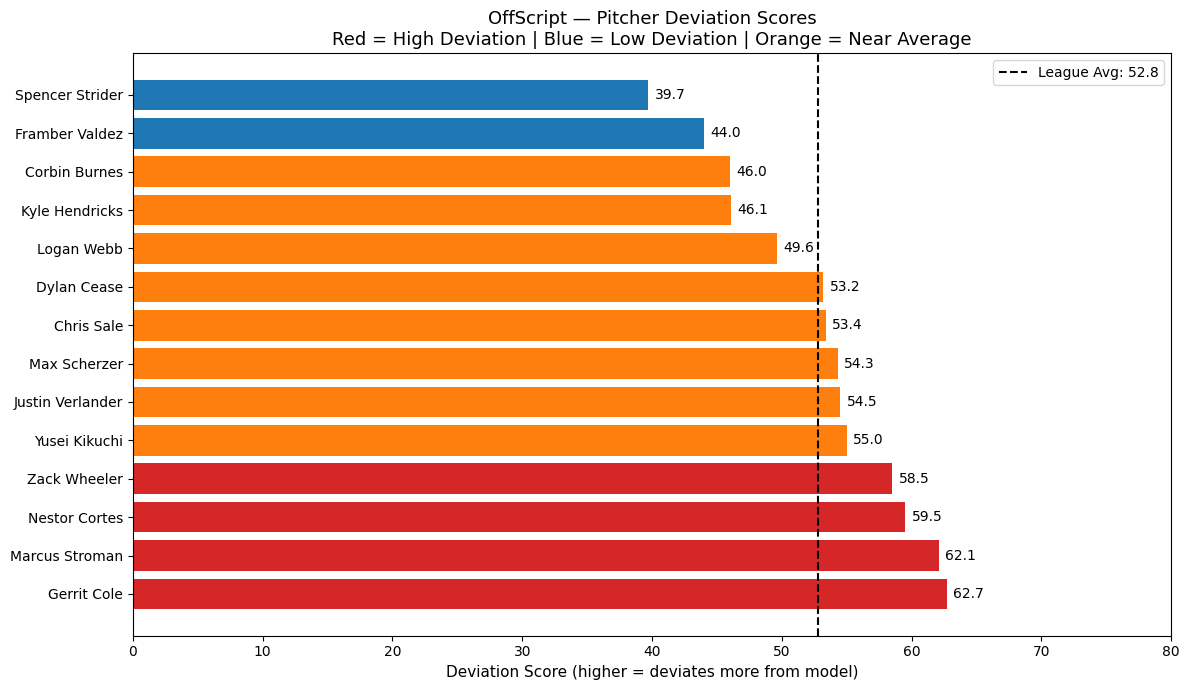

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#d62728' if s > 55 else '#1f77b4' if s < 45 else '#ff7f0e' 
          for s in deviation_summary['deviation_score']]

bars = ax.barh(deviation_summary['pitcher_name'], 
               deviation_summary['deviation_score'],
               color=colors)

# Add value labels on bars
for bar, val in zip(bars, deviation_summary['deviation_score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

# Add league average line
avg_deviation = deviation_summary['deviation_score'].mean()
ax.axvline(x=avg_deviation, color='black', linestyle='--', 
           linewidth=1.5, label=f'League Avg: {avg_deviation:.1f}')

ax.set_xlabel("Deviation Score (higher = deviates more from model)", 
              fontsize=11)
ax.set_title("OffScript — Pitcher Deviation Scores\n"
             "Red = High Deviation | Blue = Low Deviation | "
             "Orange = Near Average", fontsize=13)
ax.legend()
ax.set_xlim(0, 80)
plt.tight_layout()
plt.savefig('../reports/figures/deviation_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Deviation by Count State

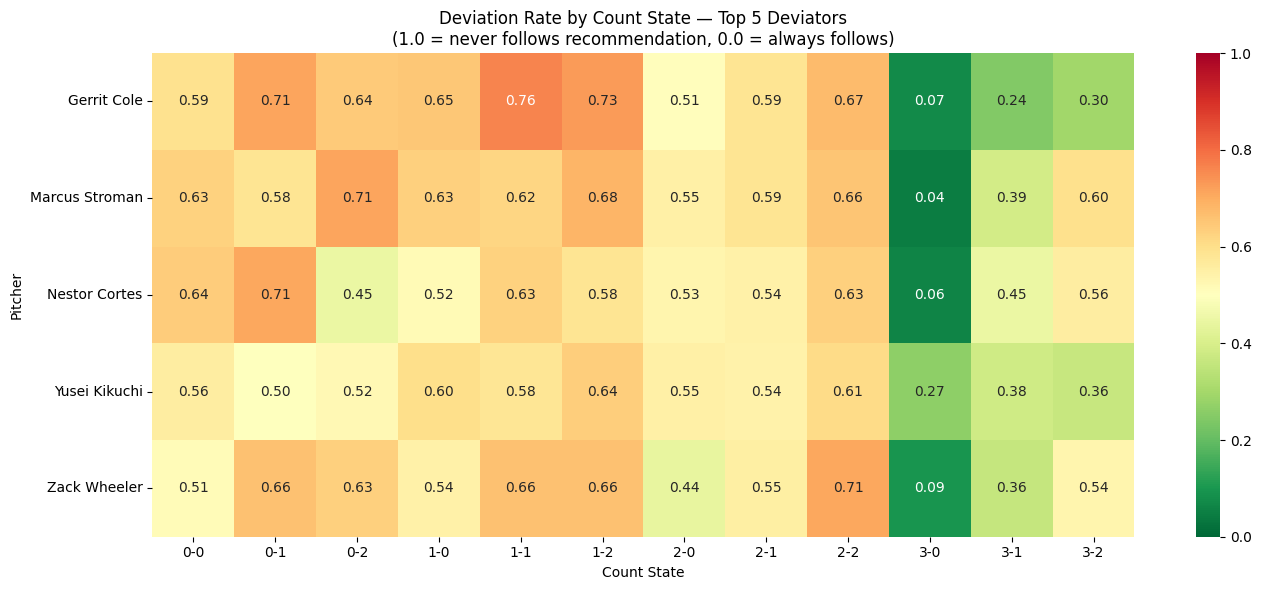

In [10]:
# Deviation rate by count state for each pitcher
count_deviation = data.groupby(
    ['pitcher_name', 'count']
)['followed_recommendation'].mean().reset_index()
count_deviation['deviation_rate'] = (
    1 - count_deviation['followed_recommendation']
)

# Focus on your top 5 deviators for clarity
top_deviators = deviation_summary.head(5)['pitcher_name'].tolist()
count_dev_top = count_deviation[
    count_deviation['pitcher_name'].isin(top_deviators)
]

# Pivot for heatmap
count_pivot = count_dev_top.pivot(
    index='pitcher_name', 
    columns='count', 
    values='deviation_rate'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(count_pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            ax=ax,
            vmin=0,
            vmax=1)
ax.set_title("Deviation Rate by Count State — Top 5 Deviators\n"
             "(1.0 = never follows recommendation, "
             "0.0 = always follows)", fontsize=12)
ax.set_xlabel("Count State")
ax.set_ylabel("Pitcher")
plt.tight_layout()
plt.savefig('../reports/figures/deviation_by_count.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Deviation by Batter Handedness

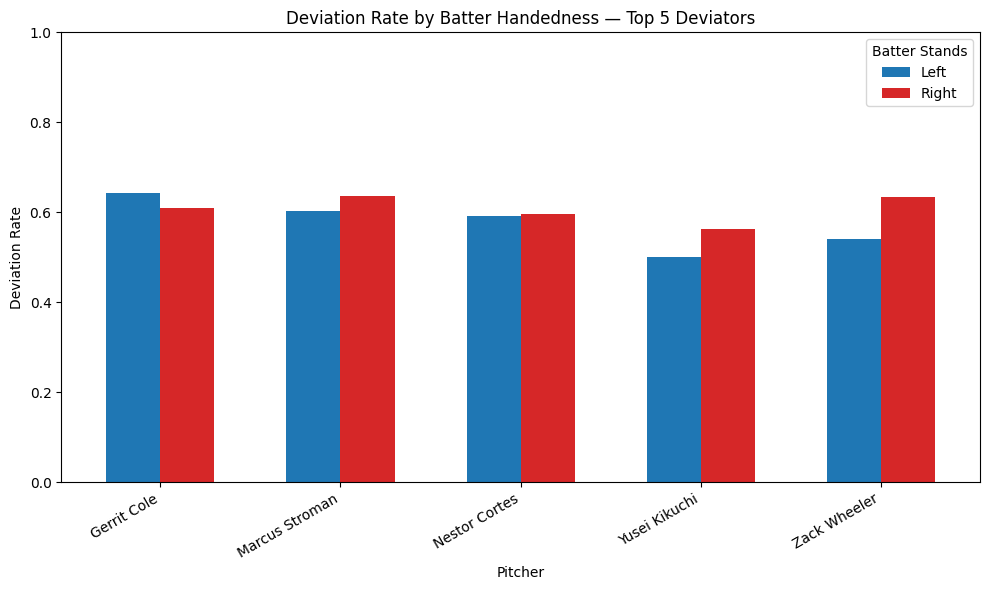

In [11]:
# Does deviation pattern change based on batter handedness?
hand_deviation = data.groupby(
    ['pitcher_name', 'stand']
)['followed_recommendation'].mean().reset_index()
hand_deviation['deviation_rate'] = (
    1 - hand_deviation['followed_recommendation']
)

# Filter to top deviators
hand_dev_top = hand_deviation[
    hand_deviation['pitcher_name'].isin(top_deviators)
]

fig, ax = plt.subplots(figsize=(10, 6))
hand_pivot = hand_dev_top.pivot(
    index='pitcher_name',
    columns='stand',
    values='deviation_rate'
)
hand_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#d62728'],
                width=0.6)
ax.set_title("Deviation Rate by Batter Handedness — Top 5 Deviators",
             fontsize=12)
ax.set_ylabel("Deviation Rate")
ax.set_xlabel("Pitcher")
ax.legend(title="Batter Stands", labels=['Left', 'Right'])
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/deviation_by_handedness.png',
            dpi=150, bbox_inches='tight')
plt.show()

## What Pitches They Throw Instead

In [13]:
# For deviating pitches only — what did they throw vs what was recommended
deviations_only = data[~data['followed_recommendation']].copy()

def deviation_substitution(pitcher_name):
    """Show what a pitcher throws instead of the recommendation."""
    pdf = deviations_only[deviations_only['pitcher_name'] == pitcher_name]
    
    substitution = pdf.groupby(
        ['recommended_pitch', 'pitch_type']
    ).size().reset_index(name='count')
    
    substitution['pct'] = (
        substitution.groupby('recommended_pitch')['count']
        .transform(lambda x: x / x.sum() * 100)
        .round(1)
    )
    
    return substitution.sort_values(
        ['recommended_pitch', 'count'], ascending=[True, False]
    )

# Print substitution patterns for top deviators
for name in top_deviators:
    print(f"\n=== {name} — Deviation Substitutions ===")
    print(f"(When model recommends X, pitcher throws Y)")
    sub = deviation_substitution(name)
    print(sub[sub['pct'] > 10].to_string(index=False))


=== Gerrit Cole — Deviation Substitutions ===
(When model recommends X, pitcher throws Y)
recommended_pitch pitch_type  count   pct
               CH         FF      2  66.7
               CH         SL      1  33.3
               FC         FF     15  48.4
               FC         CH      7  22.6
               FC         KC      4  12.9
               FF         SL    327  43.2
               FF         FC    204  26.9
               FF         KC    130  17.2
               FF         CH     79  10.4
               KC         FF   1321  55.6
               KC         SL    535  22.5
               KC         FC    274  11.5
               SI         SL      1 100.0
               SL         FF     84  67.7
               SL         FC     24  19.4
               SL         KC     15  12.1

=== Marcus Stroman — Deviation Substitutions ===
(When model recommends X, pitcher throws Y)
recommended_pitch pitch_type  count  pct
               CU         FF     41 64.1
               CU  

## Hypothesis Generation

## Initial Deviation Hypotheses

### Gerrit Cole
Cole systematically avoids his knuckle curve (KC) in situations where 
the model recommends it, substituting his fastball (55.6%) and slider 
(22.5%) instead. Simultaneously he replaces recommended fastballs with 
sliders 43.2% of the time. This suggests Cole treats his slider as his 
primary putaway pitch rather than his knuckle curve, potentially 
reflecting greater confidence in his slider's consistency at the elite 
level or a deliberate deception strategy of using his fastball to set 
up the slider rather than the knuckle curve.

### Marcus Stroman
The model frequently recommends a splitter (FS) that Stroman largely 
avoids, substituting fastball (51.2%), cutter (23.1%), and curveball 
(20.6%) instead. Stroman is known primarily as a sinker/ground ball 
pitcher whose arsenal is built around fastball variants and a curveball 
rather than a splitter. This deviation likely reflects arsenal 
composition — the model may be recommending a pitch Stroman throws 
infrequently or with limited effectiveness.

### Nestor Cortes
Cortes shows a strong preference for his fastball over the cutter and 
sweeper that the model frequently recommends. Given his unorthodox 
delivery and deceptive mechanics, this may reflect a philosophy of 
letting his release point do the work rather than relying on pitch 
movement variation. His fastball may play up significantly beyond 
its raw metrics due to his unusual arm angle.

### Zack Wheeler
Wheeler substitutes his four seam fastball for his sinker in 73.5% 
of sinker-recommended situations. This likely reflects Wheeler using 
his fastball and sinker as situational variants of the same pitch 
concept — working down in the zone with either offering depending on 
feel and batter tendencies rather than strict situational logic.

### Yusei Kikuchi
Kikuchi shows a contradictory pattern — avoiding fastballs in fastball 
situations while over-relying on fastballs in breaking ball situations. 
This may reflect a significant mid-career philosophical shift in his 
approach, as Kikuchi dramatically reinvented himself during this period 
moving toward a slider-heavy attack. The model may be capturing his 
transitional tendencies rather than a settled approach.

## Deviation Effectiveness Analysis

In [14]:
# Define outcome effectiveness
# Positive outcomes for pitcher: strikeout, swinging strike, called strike
# Negative outcomes: hit, walk, home run

positive_outcomes = [
    'strikeout', 'swinging_strike', 'called_strike',
    'swinging_strike_blocked', 'foul', 'foul_tip'
]

negative_outcomes = [
    'single', 'double', 'triple', 'home_run', 
    'walk', 'hit_by_pitch'
]

def classify_outcome(row):
    if row['description'] in ['swinging_strike', 'called_strike',
                               'swinging_strike_blocked']:
        return 'positive'
    elif row['description'] in ['ball', 'blocked_ball']:
        return 'negative'
    elif row['events'] in ['strikeout', 'strikeout_double_play']:
        return 'positive'
    elif row['events'] in ['single', 'double', 'triple', 
                            'home_run', 'walk', 'hit_by_pitch']:
        return 'negative'
    else:
        return 'neutral'

data['outcome_class'] = data.apply(classify_outcome, axis=1)

# Compare effectiveness when following vs deviating
effectiveness = data.groupby(
    ['pitcher_name', 'followed_recommendation', 'outcome_class']
).size().reset_index(name='count')

effectiveness['pct'] = (
    effectiveness.groupby(['pitcher_name', 'followed_recommendation'])
    ['count'].transform(lambda x: x / x.sum() * 100)
)

# Pivot to compare positive outcome rates
positive_rate = effectiveness[
    effectiveness['outcome_class'] == 'positive'
].pivot_table(
    index='pitcher_name',
    columns='followed_recommendation',
    values='pct'
).round(2)

positive_rate.columns = ['deviation_positive_rate', 'followed_positive_rate']
positive_rate['deviation_advantage'] = (
    positive_rate['deviation_positive_rate'] - 
    positive_rate['followed_positive_rate']
).round(2)

positive_rate = positive_rate.sort_values('deviation_advantage', 
                                           ascending=False)

print("=== Deviation Effectiveness ===")
print("Positive outcome rate when deviating vs following recommendation")
print("Positive deviation_advantage = deviating works better")
print("Negative deviation_advantage = following recommendation works better")
print()
print(positive_rate.to_string())

=== Deviation Effectiveness ===
Positive outcome rate when deviating vs following recommendation
Positive deviation_advantage = deviating works better
Negative deviation_advantage = following recommendation works better

                  deviation_positive_rate  followed_positive_rate  deviation_advantage
pitcher_name                                                                          
Corbin Burnes                       29.98                   29.19                 0.79
Spencer Strider                     34.76                   34.91                -0.15
Kyle Hendricks                      27.52                   27.76                -0.24
Framber Valdez                      29.78                   30.11                -0.33
Zack Wheeler                        28.46                   28.84                -0.38
Nestor Cortes                       26.37                   27.14                -0.77
Justin Verlander                    25.60                   27.39                -1

## Visualize Effectiveness

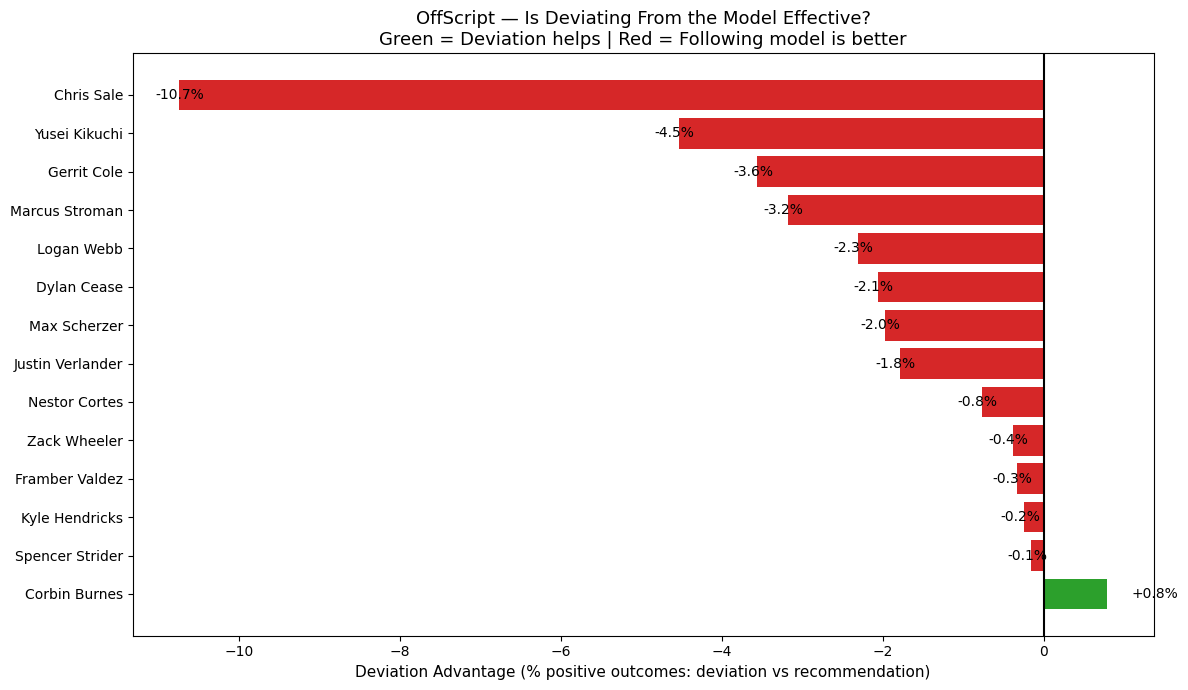

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2ca02c' if v > 0 else '#d62728' 
          for v in positive_rate['deviation_advantage']]

bars = ax.barh(positive_rate.index, 
               positive_rate['deviation_advantage'],
               color=colors)

for bar, val in zip(bars, positive_rate['deviation_advantage']):
    offset = 0.3 if val >= 0 else -0.3
    ax.text(val + offset, 
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', 
            va='center', fontsize=10)

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel("Deviation Advantage (% positive outcomes: deviation vs recommendation)",
              fontsize=11)
ax.set_title("OffScript — Is Deviating From the Model Effective?\n"
             "Green = Deviation helps | Red = Following model is better",
             fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/deviation_effectiveness.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Per Pitcher Detailed Effectiveness

In [16]:
# Deep dive on your top deviators
for name in top_deviators:
    pitcher_data = data[data['pitcher_name'] == name]
    
    dev_positive = pitcher_data[
        (~pitcher_data['followed_recommendation']) & 
        (pitcher_data['outcome_class'] == 'positive')
    ].shape[0]
    dev_total = pitcher_data[
        ~pitcher_data['followed_recommendation']
    ].shape[0]
    
    follow_positive = pitcher_data[
        (pitcher_data['followed_recommendation']) & 
        (pitcher_data['outcome_class'] == 'positive')
    ].shape[0]
    follow_total = pitcher_data[
        pitcher_data['followed_recommendation']
    ].shape[0]
    
    dev_rate = dev_positive / dev_total * 100 if dev_total > 0 else 0
    follow_rate = follow_positive / follow_total * 100 if follow_total > 0 else 0
    
    print(f"\n=== {name} ===")
    print(f"When deviating:   {dev_rate:.1f}% positive outcomes "
          f"({dev_positive}/{dev_total} pitches)")
    print(f"When following:   {follow_rate:.1f}% positive outcomes "
          f"({follow_positive}/{follow_total} pitches)")
    print(f"Deviation advantage: {dev_rate - follow_rate:+.1f}%")


=== Gerrit Cole ===
When deviating:   26.9% positive outcomes (886/3290 pitches)
When following:   30.5% positive outcomes (597/1958 pitches)
Deviation advantage: -3.6%

=== Marcus Stroman ===
When deviating:   27.2% positive outcomes (907/3332 pitches)
When following:   30.4% positive outcomes (619/2036 pitches)
Deviation advantage: -3.2%

=== Nestor Cortes ===
When deviating:   26.4% positive outcomes (640/2427 pitches)
When following:   27.1% positive outcomes (448/1651 pitches)
Deviation advantage: -0.8%

=== Zack Wheeler ===
When deviating:   28.5% positive outcomes (1156/4062 pitches)
When following:   28.8% positive outcomes (830/2878 pitches)
Deviation advantage: -0.4%

=== Yusei Kikuchi ===
When deviating:   27.7% positive outcomes (892/3217 pitches)
When following:   32.3% positive outcomes (848/2629 pitches)
Deviation advantage: -4.5%


## Effectiveness Findings

## Deviation Effectiveness Findings

### Overarching Finding
For 13 of 14 pitchers analyzed, following the model recommendation 
produces better outcomes than deviating from it, validating the 
baseline pitch selection theory. However the magnitude of the 
deviation penalty varies dramatically across pitchers, suggesting 
that some deviations are more strategic than others.

### Three Tiers of Deviation Impact

**Tier 1 — Costless Deviators (0 to -1% advantage)**
Burnes, Strider, Hendricks, Valdez, Wheeler deviate without 
meaningful cost. Their elite stuff or sophisticated sequencing 
likely compensates for unconventional selection.

**Tier 2 — Moderately Costly Deviators (-1% to -3%)**
Cortes, Verlander, Scherzer, Cease, Webb leave measurable value 
on the table but remain effective overall.

**Tier 3 — Significantly Costly Deviators (-3% and beyond)**
Stroman, Cole, Kikuchi, and Sale show the largest gaps between 
deviation and recommendation effectiveness. Sale's -10.74% gap 
is the most dramatic finding and warrants deeper investigation.

### Notable Exceptions
- **Corbin Burnes (+0.79%)** is the only pitcher where deviating 
  outperforms the model, suggesting genuine strategic sophistication
  beyond what the baseline theory captures.
- **Chris Sale (-10.74%)** represents an extreme outlier whose 
  deviation patterns appear significantly costly.

## Chris Sale Deep Dive

In [17]:
# Deep dive on Chris Sale — most dramatic deviation penalty
sale_data = data[data['pitcher_name'] == 'Chris Sale'].copy()

print("=== Chris Sale — Complete Profile ===")
print(f"Total pitches: {len(sale_data)}")
print(f"\nPitch Arsenal:")
print(sale_data['pitch_type'].value_counts())
print(f"\nOverall follow rate: {sale_data['followed_recommendation'].mean():.3f}")

# Where specifically is Sale deviating and getting hurt?
sale_dev = sale_data[~sale_data['followed_recommendation']].copy()
sale_follow = sale_data[sale_data['followed_recommendation']].copy()

# Outcome breakdown for deviating pitches
print("\n=== Sale Deviation Outcomes ===")
print(sale_dev['outcome_class'].value_counts(normalize=True).round(3) * 100)

print("\n=== Sale Following Recommendation Outcomes ===")
print(sale_follow['outcome_class'].value_counts(normalize=True).round(3) * 100)

# Which specific deviations are most costly?
sale_dev_outcomes = sale_data.groupby(
    ['recommended_pitch', 'pitch_type', 'outcome_class']
).size().reset_index(name='count')

sale_dev_outcomes['pct'] = (
    sale_dev_outcomes.groupby(['recommended_pitch', 'pitch_type'])
    ['count'].transform(lambda x: x / x.sum() * 100)
).round(1)

# Focus on negative outcomes from deviations
sale_costly = sale_dev_outcomes[
    sale_dev_outcomes['outcome_class'] == 'negative'
].sort_values('count', ascending=False)

print("\n=== Sale Most Costly Deviation Patterns ===")
print("(Recommended → Actual → Negative outcome frequency)")
print(sale_costly.head(15).to_string(index=False))

=== Chris Sale — Complete Profile ===
Total pitches: 4495

Pitch Arsenal:
pitch_type
FF    1806
SL    1761
CH     620
SI     308
Name: count, dtype: int64

Overall follow rate: 0.466

=== Sale Deviation Outcomes ===
outcome_class
negative    41.4
neutral     31.5
positive    27.1
Name: proportion, dtype: float64

=== Sale Following Recommendation Outcomes ===
outcome_class
positive    37.9
negative    34.9
neutral     27.2
Name: proportion, dtype: float64

=== Sale Most Costly Deviation Patterns ===
(Recommended → Actual → Negative outcome frequency)
recommended_pitch pitch_type outcome_class  count  pct
               SL         SL      negative    553 35.8
               SL         FF      negative    540 42.7
               SL         CH      negative    196 43.3
               FF         FF      negative    139 32.3
               SL         SI      negative    101 42.1
               FF         SL      negative     57 38.8
               CH         CH      negative     37 33.6
   

## Corbin Burnes Deep Dive

In [18]:
# Deep dive on Corbin Burnes — only pitcher where deviation helps
burnes_data = data[data['pitcher_name'] == 'Corbin Burnes'].copy()

print("=== Corbin Burnes — Deviation Success Analysis ===")
print(f"Total pitches: {len(burnes_data)}")
print(f"Follow rate: {burnes_data['followed_recommendation'].mean():.3f}")
print(f"\nPitch Arsenal:")
print(burnes_data['pitch_type'].value_counts())

# What situations does Burnes deviate in successfully?
burnes_dev = burnes_data[~burnes_data['followed_recommendation']].copy()

# Deviation success by count
burnes_count_dev = burnes_dev.groupby('count').agg(
    total=('outcome_class', 'count'),
    positive=('outcome_class', lambda x: (x == 'positive').sum())
).reset_index()
burnes_count_dev['positive_rate'] = (
    burnes_count_dev['positive'] / 
    burnes_count_dev['total'] * 100
).round(1)

print("\n=== Burnes Deviation Success by Count ===")
print(burnes_count_dev.sort_values(
    'positive_rate', ascending=False
).to_string(index=False))

# What is Burnes substituting successfully?
print("\n=== Burnes Successful Deviation Substitutions ===")
burnes_sub = burnes_dev[burnes_dev['outcome_class'] == 'positive'].groupby(
    ['recommended_pitch', 'pitch_type']
).size().reset_index(name='successful_deviations')
print(burnes_sub.sort_values(
    'successful_deviations', ascending=False
).head(10).to_string(index=False))

=== Corbin Burnes — Deviation Success Analysis ===
Total pitches: 6145
Follow rate: 0.540

Pitch Arsenal:
pitch_type
FC    3151
CU    1144
CH     675
SL     483
SI     470
ST     219
FF       3
Name: count, dtype: int64

=== Burnes Deviation Success by Count ===
count  total  positive  positive_rate
  3-1     15         7           46.7
  0-0    637       245           38.5
  1-0    260       100           38.5
  2-1    117        37           31.6
  1-1    369       116           31.4
  0-1    458       125           27.3
  2-0     31         8           25.8
  3-2     70        17           24.3
  1-2    389        94           24.2
  2-2    261        58           22.2
  0-2    221        41           18.6
  3-0      1         0            0.0

=== Burnes Successful Deviation Substitutions ===
recommended_pitch pitch_type  successful_deviations
               FC         CU                    379
               FC         CH                    155
               FC         SL        

## Situational Deviation Analysis

In [19]:
# For all pitchers — when in the game are deviations most costly?
situational = data.groupby(
    ['pitcher_name', 'followed_recommendation', 'balls', 'strikes']
).apply(lambda x: pd.Series({
    'positive_rate': (x['outcome_class'] == 'positive').mean() * 100,
    'pitch_count': len(x)
})).reset_index()

# Focus on two strike counts — highest leverage situations
two_strike = situational[situational['strikes'] == 2].copy()

two_strike_pivot = two_strike.pivot_table(
    index='pitcher_name',
    columns='followed_recommendation',
    values='positive_rate'
).round(2)

two_strike_pivot.columns = ['deviation_rate', 'follow_rate']
two_strike_pivot['two_strike_deviation_cost'] = (
    two_strike_pivot['deviation_rate'] - 
    two_strike_pivot['follow_rate']
).round(2)

print("=== Two Strike Count Deviation Analysis ===")
print("(Most critical situation — does deviation hurt more here?)")
print(two_strike_pivot.sort_values(
    'two_strike_deviation_cost'
).to_string())

=== Two Strike Count Deviation Analysis ===
(Most critical situation — does deviation hurt more here?)
                  deviation_rate  follow_rate  two_strike_deviation_cost
pitcher_name                                                            
Chris Sale                 18.54        29.00                     -10.46
Dylan Cease                18.85        24.10                      -5.25
Justin Verlander           16.53        19.33                      -2.80
Framber Valdez             24.62        27.01                      -2.39
Kyle Hendricks             13.79        15.81                      -2.02
Marcus Stroman             20.46        22.35                      -1.89
Yusei Kikuchi              21.75        22.77                      -1.02
Spencer Strider            26.50        27.30                      -0.80
Gerrit Cole                20.74        21.45                      -0.71
Nestor Cortes              20.17        20.19                      -0.02
Logan Webb           

## Save Deviation Results

In [20]:
import os

# Save deviation summary for use in future notebooks and API
os.makedirs('../data/processed', exist_ok=True)

# Save main deviation summary
deviation_summary.to_parquet(
    '../data/processed/deviation_summary.parquet', 
    index=False
)

# Save full data with recommendations attached
data.to_parquet(
    '../data/processed/pitcher_data_with_recommendations.parquet',
    index=False
)

# Save positive_rate comparison
positive_rate.to_parquet(
    '../data/processed/deviation_effectiveness.parquet'
)

print("=== Deviation Analysis Results Saved ===")
print("deviation_summary.parquet")
print("pitcher_data_with_recommendations.parquet")
print("deviation_effectiveness.parquet")

=== Deviation Analysis Results Saved ===
deviation_summary.parquet
pitcher_data_with_recommendations.parquet
deviation_effectiveness.parquet


## Early vs Late Count Deviation Breakdown

In [21]:
# Split deviation analysis into early counts vs two strike counts
# This reveals whether deviations are strategic sequencing or mistakes

def count_category(row):
    if row['strikes'] == 2:
        return 'two_strike'
    elif row['balls'] >= 3:
        return 'hitter_count'
    elif row['strikes'] == 0 and row['balls'] == 0:
        return 'first_pitch'
    else:
        return 'middle_count'

data['count_category'] = data.apply(count_category, axis=1)

# Calculate deviation cost by count category for each pitcher
count_cat_analysis = data.groupby(
    ['pitcher_name', 'count_category', 'followed_recommendation']
).apply(lambda x: pd.Series({
    'positive_rate': (x['outcome_class'] == 'positive').mean() * 100,
    'pitch_count': len(x)
})).reset_index()

# Pivot to get deviation advantage by count category
cat_pivot = count_cat_analysis.pivot_table(
    index=['pitcher_name', 'count_category'],
    columns='followed_recommendation',
    values='positive_rate'
).reset_index()

cat_pivot.columns = ['pitcher_name', 'count_category', 
                     'deviation_rate', 'follow_rate']
cat_pivot['deviation_cost'] = (
    cat_pivot['deviation_rate'] - cat_pivot['follow_rate']
).round(2)

# Focus on your most interesting pitchers
interesting_pitchers = [
    'Gerrit Cole', 'Chris Sale', 'Corbin Burnes', 
    'Dylan Cease', 'Yusei Kikuchi'
]

print("=== Deviation Cost by Count Category ===")
print("Negative = following model is better")
print("Positive = deviating is better\n")

for name in interesting_pitchers:
    pitcher_cat = cat_pivot[
        cat_pivot['pitcher_name'] == name
    ][['count_category', 'deviation_cost', 
       'deviation_rate', 'follow_rate']].set_index('count_category')
    print(f"\n{name}:")
    print(pitcher_cat.round(2).to_string())

=== Deviation Cost by Count Category ===
Negative = following model is better
Positive = deviating is better


Gerrit Cole:
                deviation_cost  deviation_rate  follow_rate
count_category                                             
first_pitch              -2.45           37.99        40.44
hitter_count             -7.62           32.00        39.62
middle_count             -3.48           25.99        29.47
two_strike               -2.00           19.61        21.62

Chris Sale:
                deviation_cost  deviation_rate  follow_rate
count_category                                             
first_pitch             -13.49           37.76        51.25
hitter_count            -18.50           24.00        42.50
middle_count             -9.20           26.87        36.07
two_strike               -9.40           19.46        28.87

Corbin Burnes:
                deviation_cost  deviation_rate  follow_rate
count_category                                             
first_p

In [ ]:
## Dylan Cease Two Strike Investi